In [67]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [68]:
import sys
import os
sys.path.append(os.path.abspath("/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main"))

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import multivariate_normal
from sklearn.linear_model import LinearRegression
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sparsecca import cca_pmd

## zscore

In [70]:
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/Bayesian_latest_phase2(5.18).csv')

wt_df = data[data['mutated_genes'].str.startswith('WT')]
wt_stats = wt_df.groupby('light_regime')['y2_slope'].agg(['mean', 'std']).reset_index()
wt_stats = wt_stats.rename(columns={'mean': 'WT_mean', 'std': 'WT_std'})

mutant_means = data.groupby(['mutant_ID', 'mutated_genes', 'light_regime'])['y2_slope'].mean().reset_index()
mutant_means = mutant_means.merge(wt_stats, on='light_regime', how='left')
mutant_means['z_score'] = (mutant_means['y2_slope'] - mutant_means['WT_mean']) / mutant_means['WT_std']
mutant_means = mutant_means[~mutant_means['mutated_genes'].str.startswith('WT')]
mutant_means.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/mutant_level_zscores.csv', index=False)
print(mutant_means.head())


           mutant_ID  mutated_genes light_regime  y2_slope   WT_mean  \
0  LMJ.RY0402.038618  Cre17.g708800  10min-10min -0.003318 -0.002158   
1  LMJ.RY0402.038618  Cre17.g708800    1min-1min -0.002455 -0.001454   
2  LMJ.RY0402.038618  Cre17.g708800    1min-5min -0.002059 -0.002028   
3  LMJ.RY0402.038618  Cre17.g708800       20h_HL -0.005469 -0.003809   
4  LMJ.RY0402.038618  Cre17.g708800       20h_ML -0.003024 -0.001820   

     WT_std   z_score  
0  0.000662 -1.752652  
1  0.000643 -1.556346  
2  0.000455 -0.069110  
3  0.000871 -1.907442  
4  0.000565 -2.130970  


#### Split the genes

In [71]:
def split_genes_with_counts(data):
    rows = []
    for _, row in data.iterrows():
        full_genes = str(row['mutated_genes']).strip()
        genes = [g.strip() for g in full_genes.replace('&', ',').split(',') if g.strip()]
        mutation_count = len(genes) + 1
        for gene in genes:
            new_row = row.copy()
            new_row['mutated_genes'] = gene
            new_row['full_mutated_genes'] = full_genes
            new_row['mutation_count'] = mutation_count
            # Append mutation count to mutant_ID
            new_row['mutant_ID'] = f"{row['mutant_ID']}({mutation_count})"
            rows.append(new_row)
    data_expanded = pd.DataFrame(rows).reset_index(drop=True)
    if data_expanded.empty:
        print("Warning: no rows generated in split_genes_with_counts")
    return data_expanded

data = mutant_means#pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/Bayesian_latest_phase2(5.18).csv')
data = split_genes_with_counts(data)
#data.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/Bayesian_splitgenes_latest_phase2(5.18).csv', index=False)

## Sparse CCA

use the z-scores maybe instead of theplots

In [77]:
K = 4
penalty_x = 0.3
penalty_y = 0.3

df = data#pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/Bayesian_splitgenes_latest_phase2(5.18).csv')
df = df[~(df['mutant_ID']== 'WT')]  #
df = df[df['mutated_genes'].notna() & df['mutant_ID'].notna()]
df = df[~(df['light_regime'].isin(['10min-10min', '5min-5min', '1min-5min', '20h_ML']))]

# Gene presence/absence matrix : X
df['presence'] = 1
X = df.pivot_table(index='mutant_ID', columns='mutated_genes',
                   values='presence', fill_value=0)
# Phenotype matrix : Y
Y = df.pivot_table(index='mutant_ID', columns='light_regime',
                   values='y2_slope', aggfunc='mean')
common = X.index.intersection(Y.index)
X, Y = X.loc[common], Y.loc[common]
Y = Y.fillna(Y.mean())
Y = Y.clip(lower=-1e6, upper=1e6)
X = X.loc[:, X.var() > 0]

X_scaled = StandardScaler().fit_transform(X)
Y_scaled = StandardScaler().fit_transform(Y)
mask = np.isfinite(X_scaled).all(axis=1) & np.isfinite(Y_scaled).all(axis=1)
X_scaled = X_scaled[mask]
Y_scaled = Y_scaled[mask]

print("Cleaned X:", X_scaled.shape, "Cleaned Y:", Y_scaled.shape)
U, V, D = cca_pmd(
    X_scaled, Y_scaled,
    penaltyx=penalty_x,
    penaltyz=penalty_y,
    K=K,
    standardize=False
)
results = []
for k in range(K):
    X_ck = X_scaled @ U[:, k]
    Y_ck = Y_scaled @ V[:, k]
    corr_k = np.corrcoef(X_ck, Y_ck)[0, 1]
    important_genes = X.columns[(abs(U[:, k]) > 1e-4)]
    important_phenos = Y.columns[(abs(V[:, k]) > 1e-4)]
    results.append({
        "component": k+1,
        "correlation": corr_k,
        "genes": list(important_genes),
        "phenotypes": list(important_phenos)
    })
for res in results:
    print(f"\n=== Canonical Component {res['component']} ===")
    print(f"Correlation: {res['correlation']:.3f}")
    print("Correlated genes:", res['genes'][:15], "..." if len(res['genes']) > 15 else "")
    print("Correlated light regimes:", res['phenotypes'])

genes_used = X.columns
phenos_used = Y.columns
records = []
for k in range(K):
    X_ck = X_scaled @ U[:, k]
    Y_ck = Y_scaled @ V[:, k]
    corr_k = np.corrcoef(X_ck, Y_ck)[0, 1]
    for gene_idx, gene in enumerate(genes_used):
        if abs(U[gene_idx, k]) > 1e-4:
            for pheno_idx, pheno in enumerate(phenos_used):
                if abs(V[pheno_idx, k]) > 1e-4:
                    records.append({
                        "component": k+1,
                        "correlation": corr_k,
                        "gene": gene,
                        "gene_weight": abs(U[gene_idx, k]),
                        "light_regime": pheno,
                        "pheno_weight": abs(V[pheno_idx, k])
                    })

results_df = pd.DataFrame(records)
results_df.to_csv(
    "/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/cca_correlated_genes_lightregimes_with_weights.csv",
    index=False
)

Cleaned X: (1074, 586) Cleaned Y: (1074, 4)

=== Canonical Component 1 ===
Correlation: 0.617
Correlated genes: ['Cre01.g008200', 'Cre01.g012150', 'Cre01.g012650', 'Cre01.g015200', 'Cre01.g016556', 'Cre01.g017200', 'Cre01.g018700', 'Cre01.g019550', 'Cre01.g019750', 'Cre01.g019850', 'Cre01.g022900', 'Cre01.g024800', 'Cre01.g025400', 'Cre01.g025450', 'Cre01.g025500'] ...
Correlated light regimes: ['30s-30s']

=== Canonical Component 2 ===
Correlation: 0.499
Correlated genes: ['Cre01.g012150', 'Cre01.g012850', 'Cre01.g021550', 'Cre01.g030750', 'Cre01.g032850', 'Cre02.g076987', 'Cre02.g080900', 'Cre02.g089237', 'Cre02.g090100', 'Cre02.g095058', 'Cre02.g095081', 'Cre02.g095115', 'Cre02.g095137', 'Cre02.g098750', 'Cre02.g108500'] ...
Correlated light regimes: ['20h_HL']

=== Canonical Component 3 ===
Correlation: 0.524
Correlated genes: ['Cre01.g011901', 'Cre01.g012150', 'Cre01.g012850', 'Cre01.g017200', 'Cre01.g021550', 'Cre01.g025400', 'Cre01.g039550', 'Cre01.g064727', 'Cre02.g093300', 'Cr

In [17]:
## transform so it matches the R files
df = pd.read_csv("/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/cca_correlated_genes_lightregimes_with_weights.csv")
all_light_regimes = ["1min-1min", "30s-30s", "20h_HL", "20h_ML",
                     "2h-2h", "10min-10min", "5min-5min", "1min-5min"]
formatted_rows = []
for comp, subdf in df.groupby("component"):
    regime_weights = dict(zip(subdf["light_regime"], subdf["pheno_weight"]))
    for regime in all_light_regimes:
        weight = regime_weights.get(regime, 0)
        formatted_rows.append({
            "component": comp,
            "type": "light_regime",
            "name": regime,
            "weight": weight
        })
    gene_sub = subdf.dropna(subset=["gene"])
    for _, row in gene_sub.iterrows():
        formatted_rows.append({
            "component": comp,
            "type": "gene",
            "name": row["gene"],
            "weight": row["gene_weight"]
        })

formatted_df = pd.DataFrame(formatted_rows)
formatted_df.to_csv("formatted_component_weights.csv", index=False)
formatted_df = formatted_df.drop_duplicates()
formatted_df.to_csv("/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/sCCA/python_scca_pmd_results.csv", index=False)
print(formatted_df.head())

   component          type       name  weight
0          1  light_regime  1min-1min     0.0
1          1  light_regime    30s-30s     1.0
2          1  light_regime     20h_HL     0.0
3          1  light_regime     20h_ML     0.0
4          1  light_regime      2h-2h     0.0


In [18]:
## Permute to Shuffle the mapping between X and Y (break the true association).
def permutation_fdr(X, Y, penaltyx, penaltyz, K, n_perm=100):
    observed_selected = (np.abs(U) > 1e-4).sum()
    null_selected = []
    X_np = np.asarray(X)
    Y_np = np.asarray(Y)
    for _ in range(n_perm):
        perm_idx = np.random.permutation(Y_np.shape[0])
        Y_perm = Y_np[perm_idx, :]  
        U_perm, V_perm, _ = cca_pmd(
            X_np, Y_perm,
            penaltyx=penaltyx,
            penaltyz=penaltyz,
            K=K,
            standardize=False
        )
        null_selected.append((np.abs(U_perm) > 1e-4).sum())
    expected_fp = np.mean(null_selected)
    fdr = expected_fp / max(observed_selected, 1)
    return fdr
fdr_est = permutation_fdr(X_scaled, Y_scaled, penalty_x, penalty_y, K, n_perm=1000)
print("Estimated FDR:", fdr_est)

Estimated FDR: 0.9645221774193549


## most signif genes

In [11]:
list_fl = results_df[((results_df['light_regime']=='30s-30s') & (results_df['gene_weight']>0.2))]['gene']

print(list(list_fl))

[]


In [13]:
from Scripts_Imane import Plots
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/Bayesian_latest_phase2(5.18).csv')
#data = split_genes_with_counts(data)
Plots.plot_slope_lights_trend_log(data, list_fl)

In [16]:
genes_to_flag = [
    'Cre12.g531900', 'Cre16.g661200', 'Cre07.g314800',
    'Cre13.g588150', 'Cre06.g278110', 'Cre05.g235800',
    'Cre02.g105350', 'Cre13.g581900', 'Cre07.g323450',
    'Cre15.g635800'
]
flagged_hits = results_df[results_df['gene'].isin(genes_to_flag)].copy()
found_genes = set(flagged_hits['gene'])
missing_genes = set(genes_to_flag) - found_genes
print("=== Flagged Genes Found in CCA ===")
print(flagged_hits[['component','light_regime','gene','gene_weight','pheno_weight']].sort_values(['gene','component']))
print("\n=== Flagged Genes Missing from CCA ===")
print(missing_genes if missing_genes else "None — all flagged genes found!")
flagged_hits.to_csv(
    "/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/flagged_genes_in_cca_with_weights.csv",
    index=False
)

=== Flagged Genes Found in CCA ===
     component light_regime           gene  gene_weight  pheno_weight
142          2        2h-2h  Cre02.g105350     0.000201           1.0
373          4    1min-5min  Cre05.g235800     0.004599           1.0
169          2        2h-2h  Cre07.g323450     0.042810           1.0
393          4    1min-5min  Cre07.g323450     0.032225           1.0
85           1    1min-1min  Cre12.g531900     0.395885           1.0
206          2        2h-2h  Cre12.g531900     0.107488           1.0
439          4    1min-5min  Cre12.g531900     0.617097           1.0
449          4    1min-5min  Cre13.g581900     0.151351           1.0
451          4    1min-5min  Cre13.g588150     0.208654           1.0
221          2        2h-2h  Cre15.g635800     0.020781           1.0
457          4    1min-5min  Cre15.g635800     0.059126           1.0

=== Flagged Genes Missing from CCA ===
{'Cre07.g314800', 'Cre16.g661200', 'Cre06.g278110'}


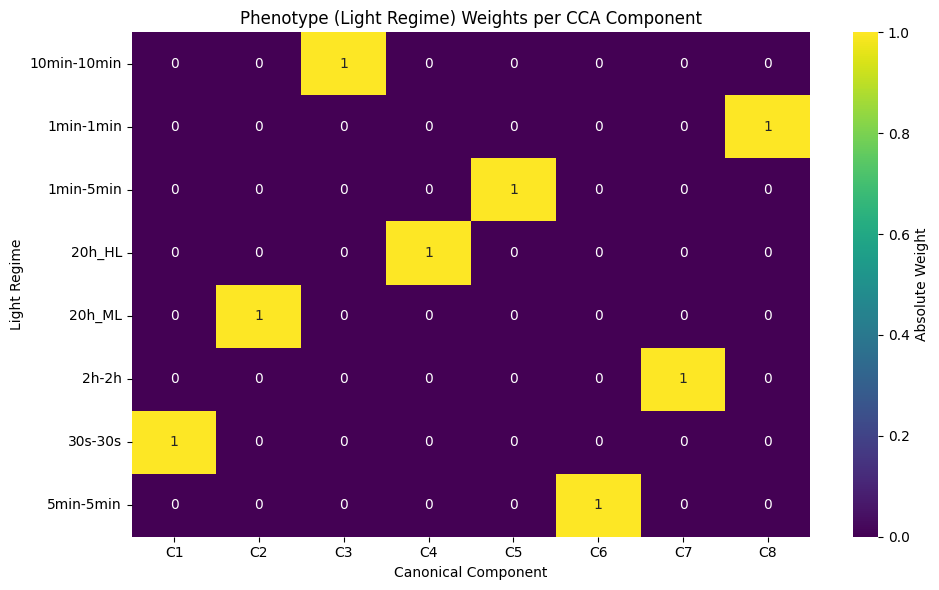

KeyError: "['Cre06.g278110'] not in index"

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

pheno_weights_df = pd.DataFrame(V, index=Y.columns, columns=[f"C{k+1}" for k in range(V.shape[1])])
plt.figure(figsize=(10,6))
sns.heatmap(pheno_weights_df.abs(), annot=True, cmap="viridis", cbar_kws={'label': 'Absolute Weight'})
plt.title("Phenotype (Light Regime) Weights per CCA Component")
plt.xlabel("Canonical Component")
plt.ylabel("Light Regime")
plt.tight_layout()
plt.show()
# Build DataFrame for gene weights (filtered)
gene_weights_df = pd.DataFrame(U, index=X.columns, columns=[f"C{k+1}" for k in range(U.shape[1])])
gene_weights_filtered = gene_weights_df.loc[genes_to_flag]

plt.figure(figsize=(10,6))
sns.heatmap(gene_weights_filtered.abs(), annot=True, cmap="magma", cbar_kws={'label': 'Absolute Weight'})
plt.title("Flagged Gene Weights per CCA Component")
plt.xlabel("Canonical Component")
plt.ylabel("Gene")
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Genes you want to highlight
genes_to_flag = ['Cre12.g531900',
'Cre16.g661200',
'Cre07.g314800',
'Cre13.g588150',
'Cre06.g278110',
'Cre05.g235800',
'Cre02.g105350',
'Cre13.g581900',
'Cre07.g323450','Cre15.g635800']
# Mutant_ID → genes mapping (aggregate multiple hits)
mutant_gene_map = df.groupby('mutant_ID')['mutated_genes'] \
                      .apply(lambda x: ','.join(set(x))).to_dict()

# Ensure X and Y are aligned and reset index to keep track
X = X.reset_index()
Y = Y.reset_index()
mutant_ids = X['mutant_ID']  # keep mutant IDs safe

# Standardize
X_scaled = StandardScaler().fit_transform(X.drop(columns='mutant_ID'))
Y_scaled = StandardScaler().fit_transform(Y.drop(columns='mutant_ID'))

# Drop bad rows after scaling
mask_X = np.isfinite(X_scaled).all(axis=1)
mask_Y = np.isfinite(Y_scaled).all(axis=1)
valid_mask = mask_X & mask_Y

X_scaled = X_scaled[valid_mask]
Y_scaled = Y_scaled[valid_mask]
valid_mutant_ids = mutant_ids[valid_mask].values

for k in range(K):
    X_ck = X_scaled @ U[:, k]
    Y_ck = Y_scaled @ V[:, k]

    scatter_df = pd.DataFrame({
        'mutant_ID': valid_mutant_ids,
        'X_c': X_ck,
        'Y_c': Y_ck
    })
    scatter_df['mutated_genes'] = scatter_df['mutant_ID'].map(mutant_gene_map)

    plt.figure(figsize=(7,6))
    plt.scatter(scatter_df['X_c'], scatter_df['Y_c'],
                color='lightgray', alpha=0.4, label='Other mutants')

    colors = plt.cm.tab10(np.linspace(0, 1, len(genes_to_flag)))
    gene_color_map = {gene: colors[i] for i, gene in enumerate(genes_to_flag)}

    for gene, color in gene_color_map.items():
        mask = scatter_df['mutated_genes'].astype(str).str.contains(gene, na=False)
        plt.scatter(scatter_df.loc[mask, 'X_c'],
                    scatter_df.loc[mask, 'Y_c'],
                    color=color, edgecolor='black', s=80, label=gene)

    plt.title(f"Canonical Component {k+1} (corr={np.corrcoef(X_ck, Y_ck)[0,1]:.2f})")
    plt.xlabel("X variate")
    plt.ylabel("Y variate")
    plt.legend()
    plt.show()


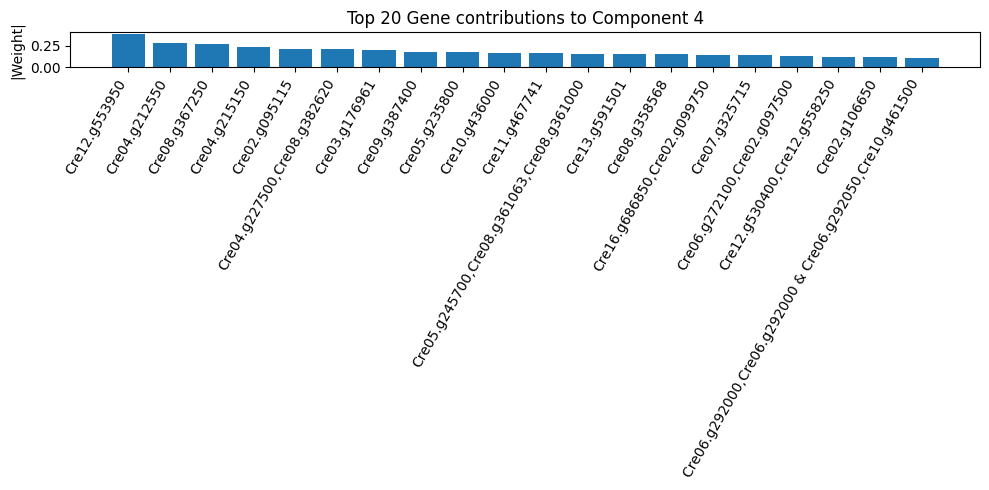

In [17]:
import matplotlib.pyplot as plt
import numpy as np

k = 3  # component index (0 = Component 1)
N = 20 # how many top genes to show

weights = np.abs(U[:,k])
top_idx = np.argsort(weights)[::-1][:N]

plt.figure(figsize=(10,5))
plt.bar(np.array(X.columns)[top_idx], weights[top_idx])
plt.title(f"Top {N} Gene contributions to Component {k+1}")
plt.ylabel("|Weight|")
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from gprofiler import GProfiler
from sklearn.preprocessing import StandardScaler
from sparsecca import cca_pmd

# === Assume you already have X, Y, and ran cca_pmd ===
# U, V, D = cca_pmd(X_scaled, Y_scaled, penaltyx=0.3, penaltyz=0.3, K=4, standardize=False)

# Capture the gene list that matches U
genes_used = X.columns[:U.shape[0]]
print(f"U shape: {U.shape}, Genes used: {len(genes_used)}")

# g:Profiler client
gp = GProfiler(return_dataframe=True)

# Parameters
K = U.shape[1]        # number of canonical components
threshold = 0.1       # weight threshold for gene selection
background_genes = genes_used.tolist()  # background = all tested genes

for k in range(K):
    print(f"\n=== Component {k+1} ===")
    weights = U[:, k]
    
    # Select genes above threshold
    selected_genes = [genes_used[i] for i in range(len(weights)) if abs(weights[i]) > threshold]
    print(f"Selected {len(selected_genes)} genes for enrichment")
    
    # Skip if no genes pass threshold
    if len(selected_genes) == 0:
        print("⚠️ No genes passed threshold; skipping enrichment.")
        continue

    # Save gene list
    pd.Series(selected_genes).to_csv(f"cca_component{k+1}_genes.txt", index=False, header=False)

    # Run GO enrichment
    enrich_results = gp.profile(
        organism='creinhardtii',
        query=selected_genes,
        no_evidences=False,
        user_threshold=0.05,
        sources=['GO:BP', 'GO:MF', 'GO:CC'],
        background=background_genes
    )

    # Handle case where no enrichment found
    if enrich_results.empty:
        print("⚠️ No significant GO terms found.")
        continue

    # Save enrichment results
    enrich_results.to_csv(f"cca_component{k+1}_GO_enrichment.csv", index=False)

    # Plot top 15 terms
    sig = enrich_results[enrich_results['p_value'] < 0.05].head(15)
    if not sig.empty:
        plt.figure(figsize=(8,6))
        plt.barh(sig['name'], -np.log10(sig['p_value']))
        plt.xlabel('-log10(p-value)')
        plt.title(f'Top GO enrichment terms (Component {k+1})')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ No GO terms below p<0.05 to plot.")


U shape: (564, 4), Genes used: 564

=== Component 1 ===
Selected 15 genes for enrichment
⚠️ No significant GO terms found.

=== Component 2 ===
Selected 23 genes for enrichment
⚠️ No significant GO terms found.

=== Component 3 ===
Selected 15 genes for enrichment
⚠️ No significant GO terms found.

=== Component 4 ===
Selected 17 genes for enrichment
⚠️ No significant GO terms found.


### Same trend graphs but with cca weights

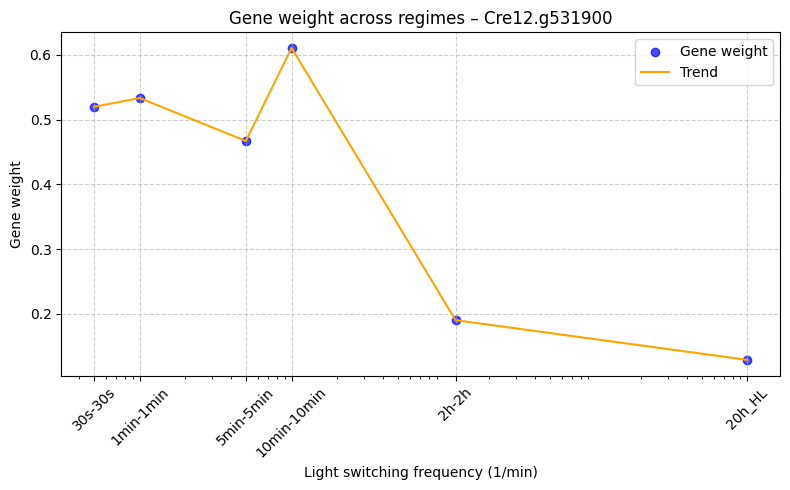

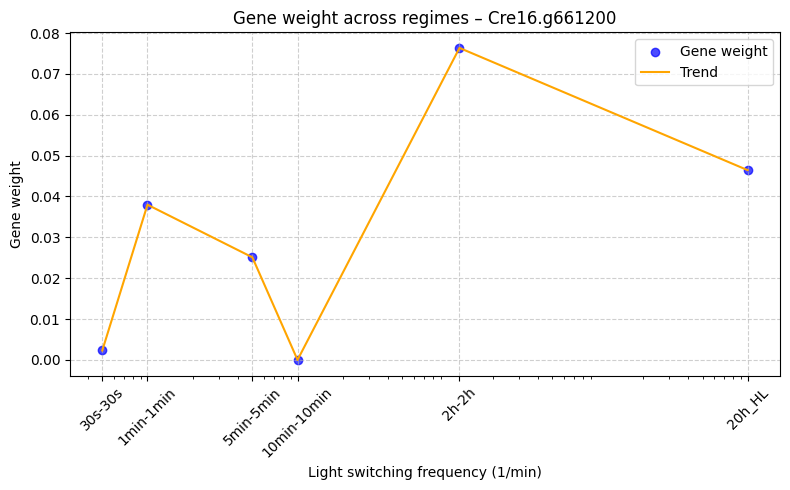

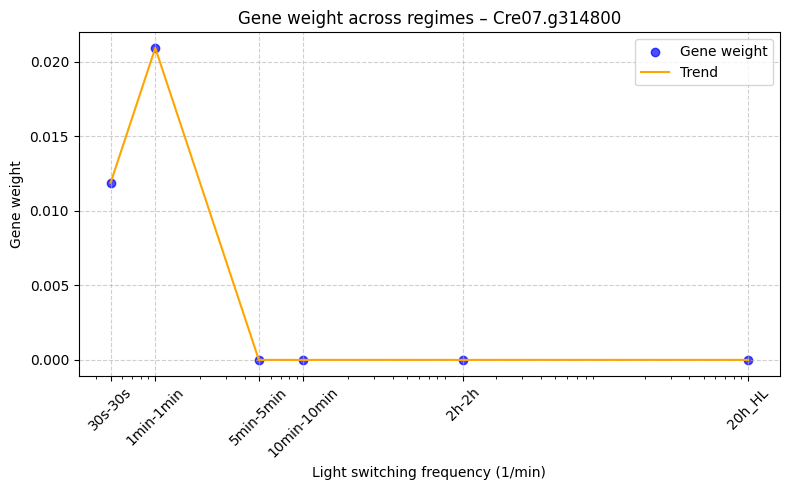

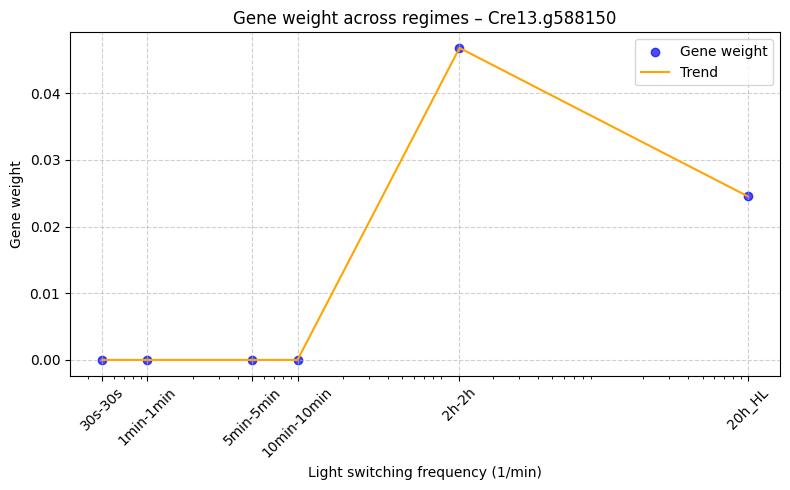

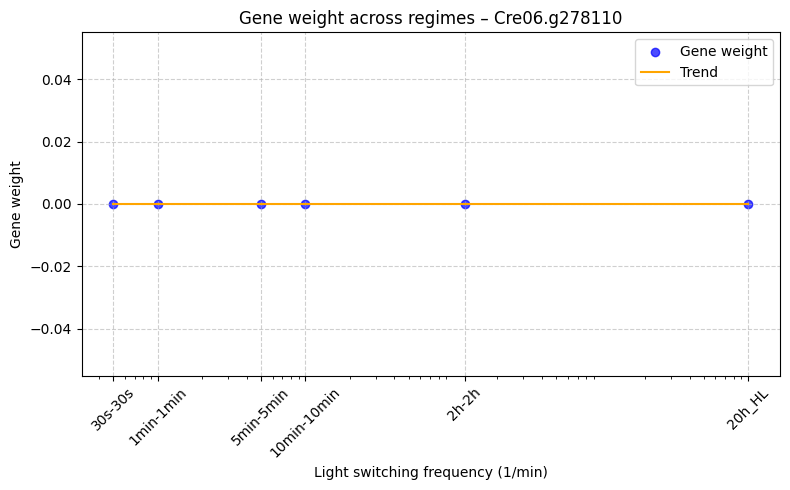

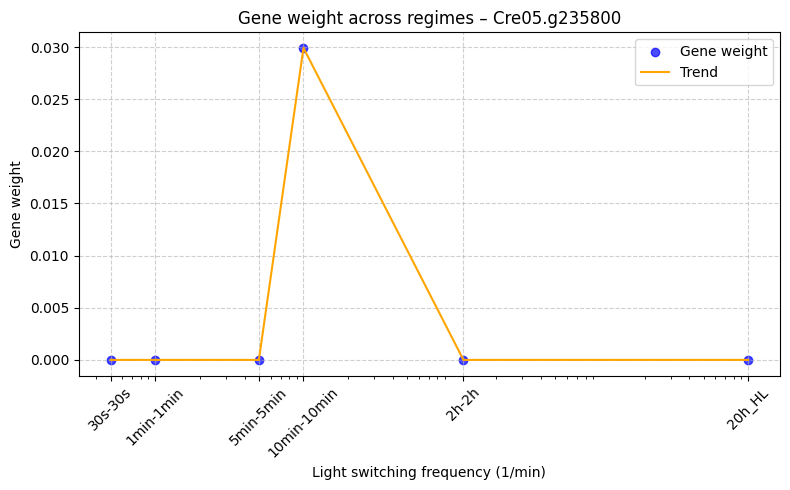

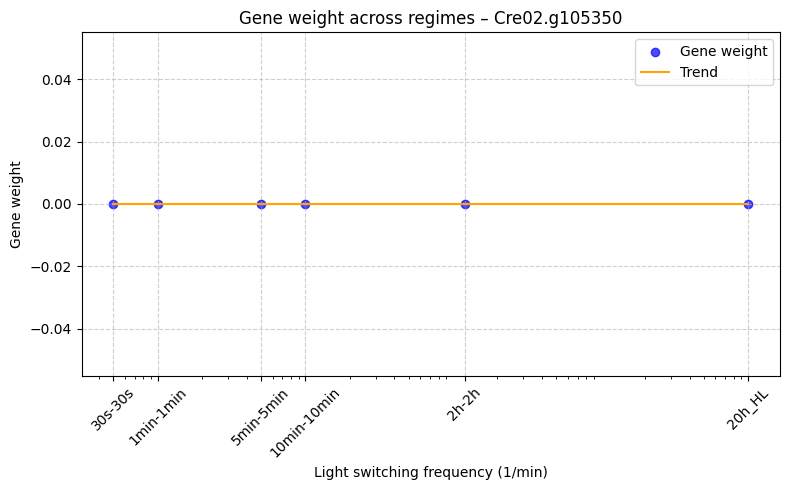

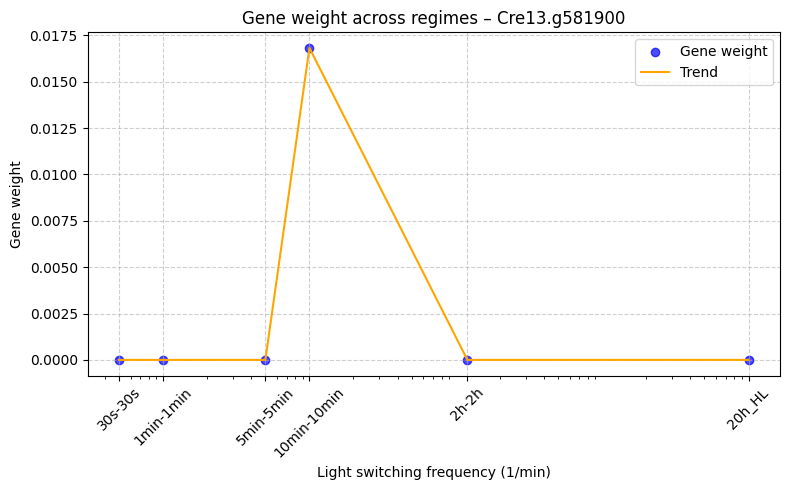

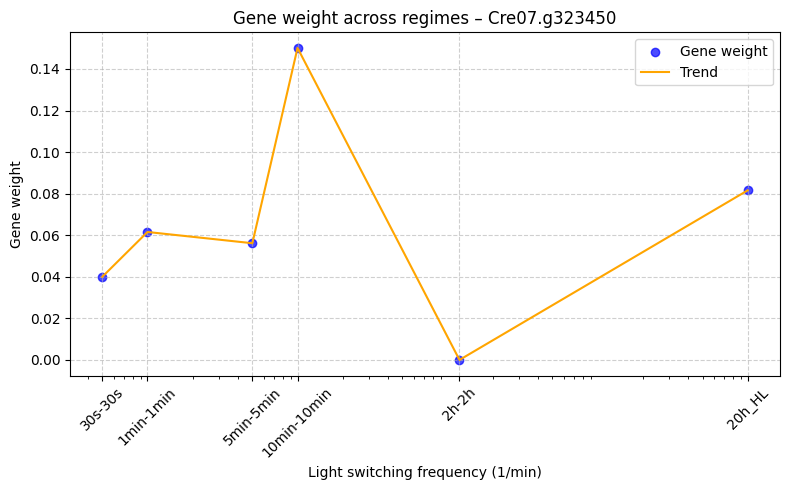

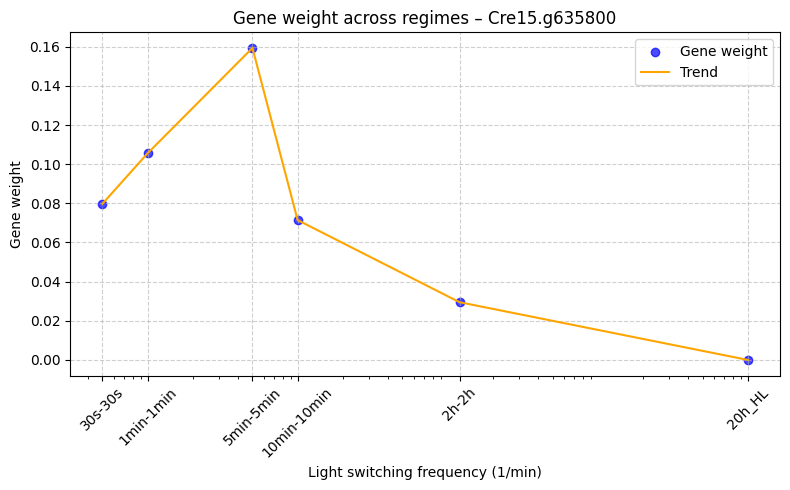

In [10]:
genes_to_flag = ['Cre12.g531900','Cre16.g661200','Cre07.g314800','Cre13.g588150','Cre06.g278110',
'Cre05.g235800','Cre02.g105350','Cre13.g581900','Cre07.g323450','Cre15.g635800']
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/cca_correlated_genes_lightregimes_with_weights.csv')
regime_to_freq = {
    '20h_HL': 10000,
    '2h-2h': 120,
    '10min-10min': 10,
    '5min-5min': 5,
    '1min-1min': 1,
    '30s-30s': 0.5
}
regime_order = list(regime_to_freq.keys())
data = data[data['light_regime'].isin(regime_order)].copy()
data['freq'] = data['light_regime'].map(regime_to_freq)
regime_df = pd.DataFrame({'light_regime': regime_order})
regime_df['freq'] = regime_df['light_regime'].map(regime_to_freq)
all_genes = genes_to_flag #sorted(data['gene'].unique()) if not data.empty else []
for gene in all_genes:
    gene_data = data[data['gene'] == gene][['light_regime', 'gene_weight']].copy()
    merged = regime_df.merge(gene_data, on='light_regime', how='left')
    merged['gene_weight'] = merged['gene_weight'].fillna(0)
    x = merged['freq'].values
    y = merged['gene_weight'].values
    plt.figure(figsize=(8, 5))
    plt.scatter(x, y, color='blue', alpha=0.7, label="Gene weight")
    plt.plot(x, y, color='orange', linestyle='-', label="Trend")
    plt.xscale('log')
    plt.xticks(ticks=[regime_to_freq[r] for r in regime_order],
        labels=regime_order,rotation=45)
    #plt.ylim(0,1)
    plt.xlabel("Light switching frequency (1/min)")
    plt.ylabel("Gene weight")
    plt.title(f"Gene weight across regimes – {gene}")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

### Other cca on R

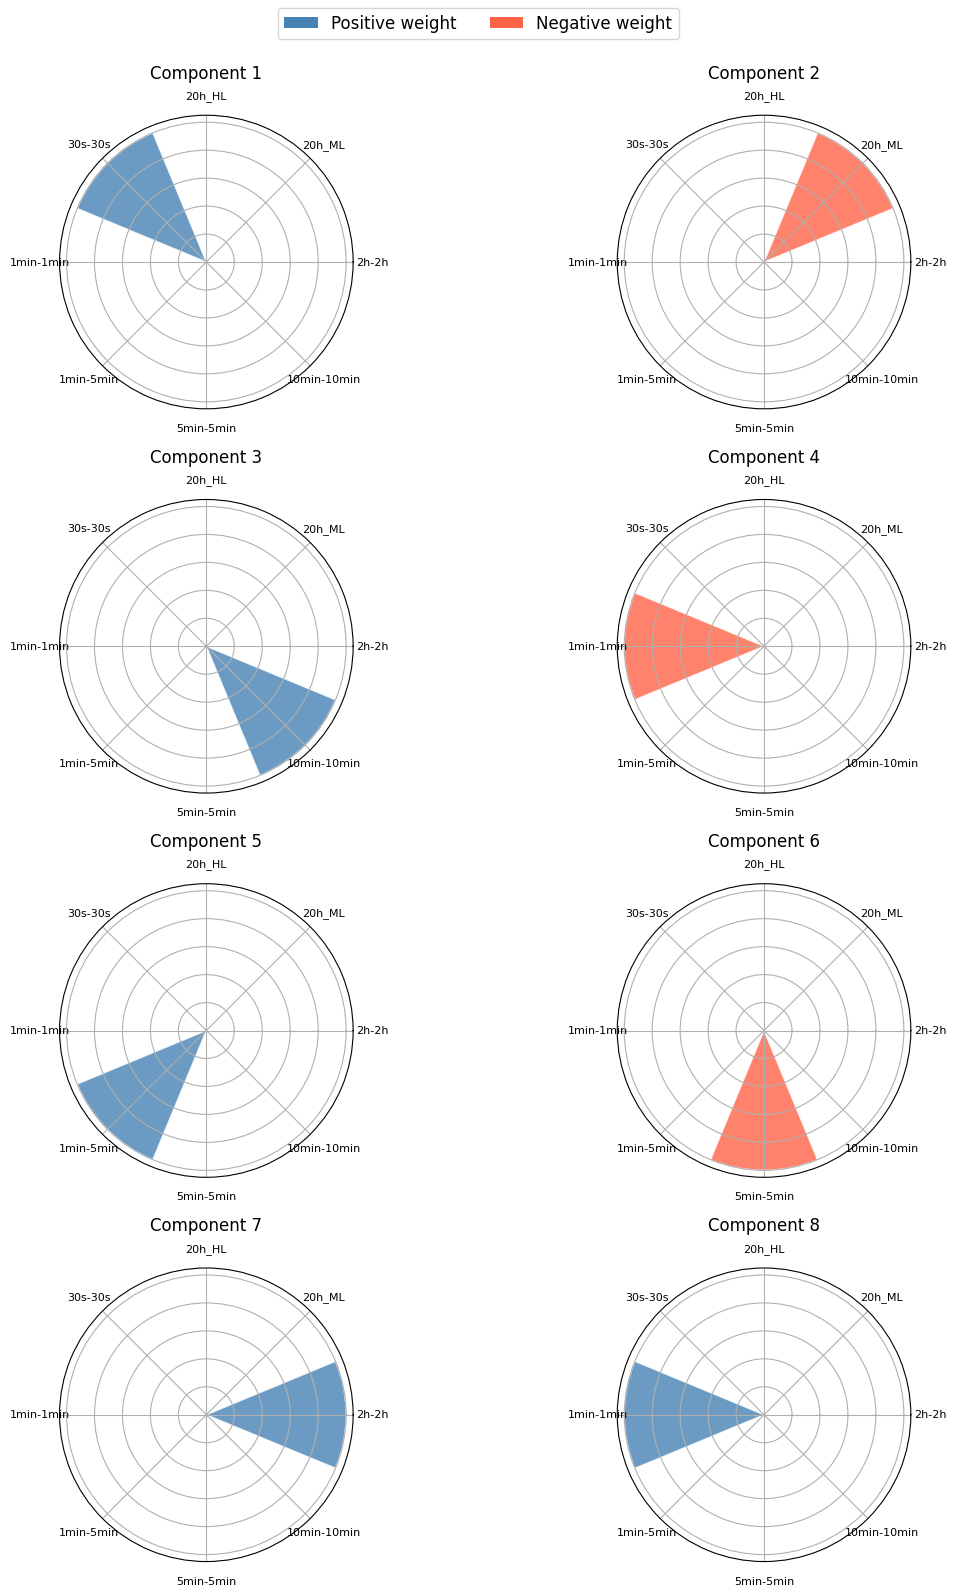

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# Load CSV
df = pd.read_csv("/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/sCCA/STANDARD_sCCA_full_results_orderedY.csv")
light_df = df[df['type'] == 'light_regime']

# Define the fixed order of light regimes
regime_order = [ "2h-2h", "20h_ML", "20h_HL", "30s-30s", "1min-1min", "1min-5min", "5min-5min", "10min-10min"]
n_regimes = len(regime_order)

components = sorted(light_df['component'].unique())

fig, axes = plt.subplots(4, 2, figsize=(12, 16), subplot_kw={'polar': True})
axes = axes.flatten()

for i, comp in enumerate(components[:8]):
    ax = axes[i]
    
    comp_data = light_df[light_df['component'] == comp].set_index('name')
    comp_data = comp_data.reindex(regime_order)  # force consistent order
    
    weights = comp_data['weight'].values
    labels = comp_data.index.values
    
    angles = np.linspace(0, 2*np.pi, n_regimes, endpoint=False)
    radii = np.abs(weights)
    colors = ['steelblue' if w > 0 else 'tomato' for w in weights]
    
    ax.bar(angles, radii, width=2*np.pi/n_regimes, color=colors,
           edgecolor='white', alpha=0.8)
    
    ax.set_xticks(angles)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_yticklabels([])
    ax.set_title(f"Component {comp}", va='bottom')

# Remove extra subplots if fewer than 8 components
for j in range(len(components), len(axes)):
    fig.delaxes(axes[j])

# Add legend
legend_elements = [Patch(facecolor='steelblue', label='Positive weight'),
                   Patch(facecolor='tomato', label='Negative weight')]
fig.legend(handles=legend_elements, loc='upper center', ncol=2, fontsize=12)

plt.tight_layout(rect=[0,0,1,0.97])
plt.show()


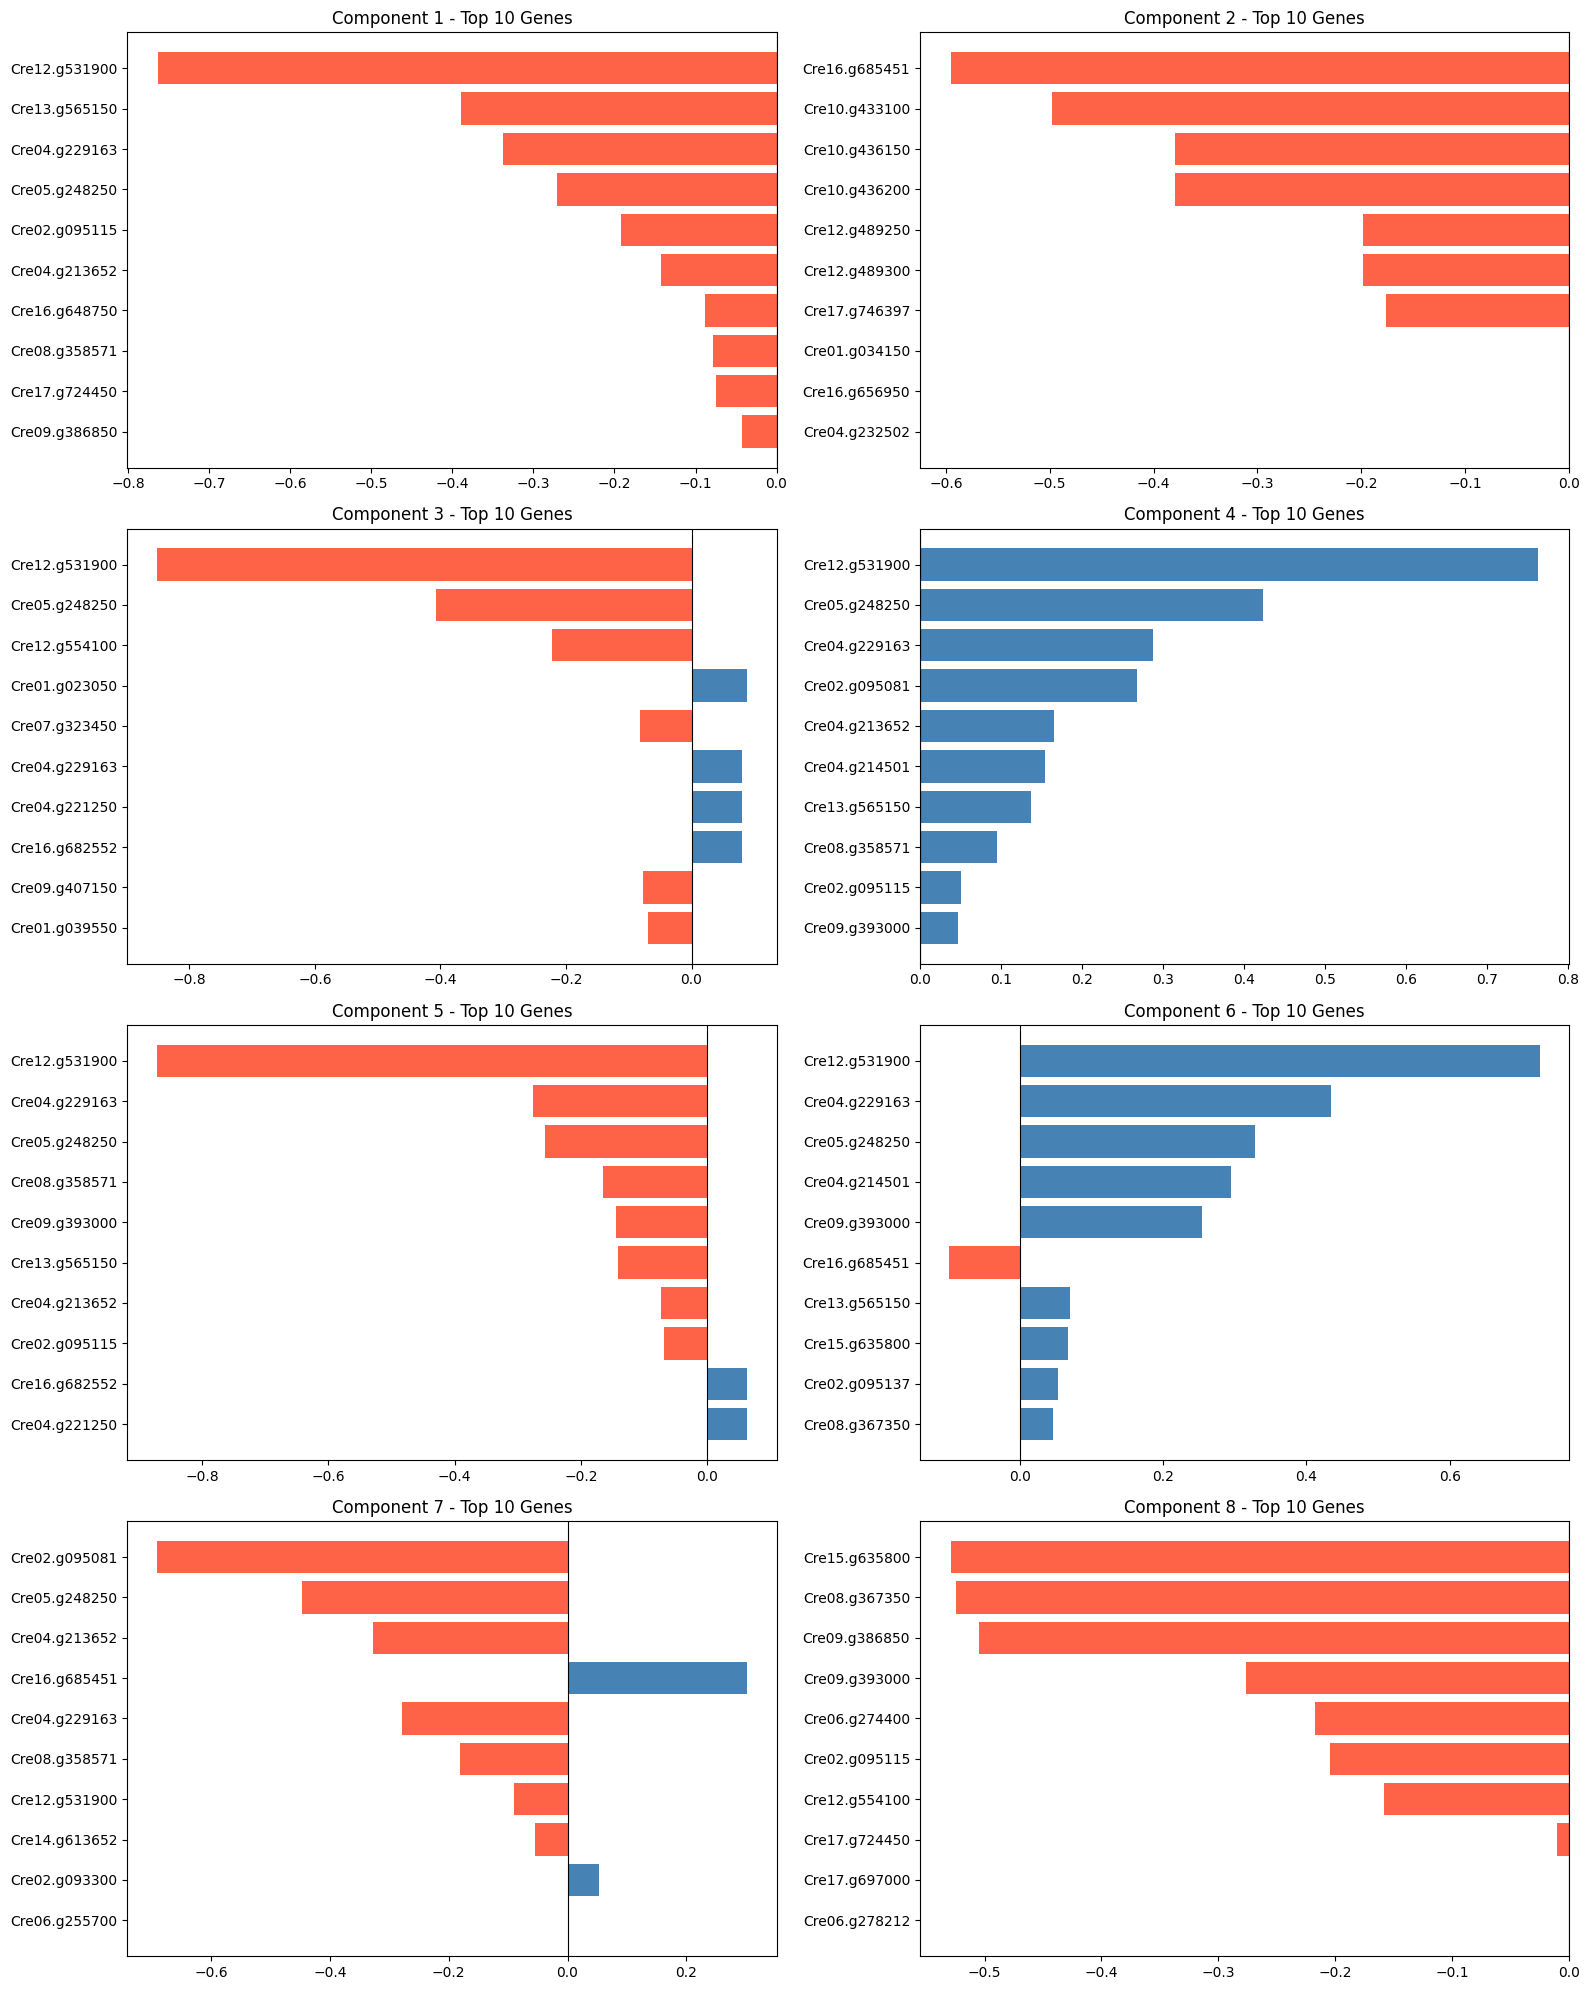

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Load results
#df = pd.read_csv("/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/sCCA/STANDARD_sCCA_full_results.csv")

# Filter to genes only
gene_df = df[df['type'] == 'gene']

# Components to plot
components = sorted(gene_df['component'].unique())

# Set up grid (e.g. 4x2 for 8 components)
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for i, comp in enumerate(components[:8]):
    ax = axes[i]
    
    comp_data = gene_df[gene_df['component'] == comp].copy()
    
    # Pick top 10 genes by absolute weight
    top_genes = comp_data.reindex(comp_data['weight'].abs().sort_values(ascending=False).index)[:10]
    
    # Plot bar chart (signed weights)
    ax.barh(top_genes['name'], top_genes['weight'], color=['steelblue' if w > 0 else 'tomato' for w in top_genes['weight']])
    
    ax.set_title(f"Component {comp} - Top 10 Genes")
    ax.axvline(0, color='black', linewidth=0.8)
    ax.invert_yaxis()  # largest bar on top

plt.tight_layout()
plt.show()


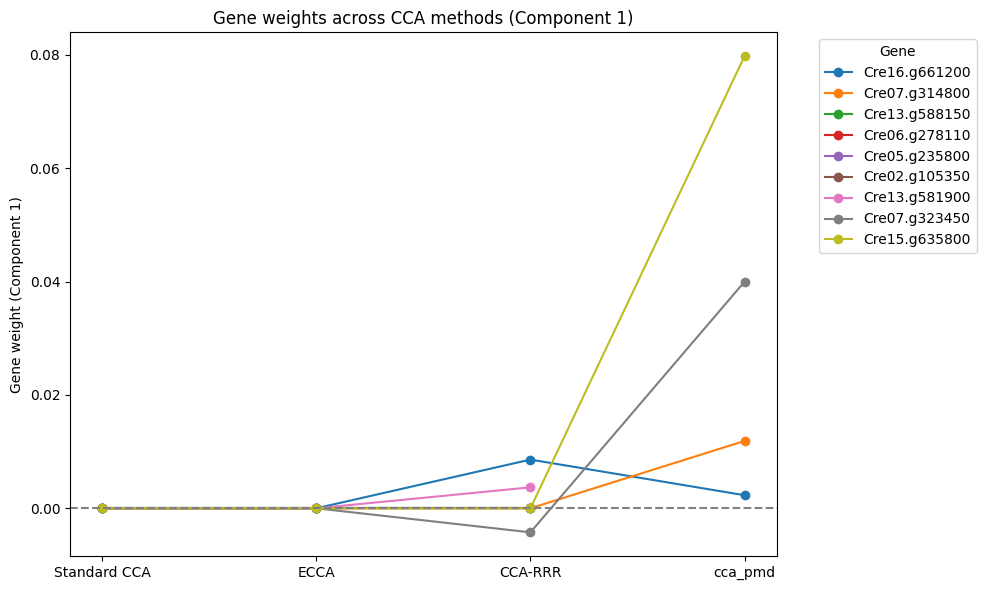

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# === Parameters ===
genes_of_interest = [
'Cre16.g661200',
'Cre07.g314800',
'Cre13.g588150',
'Cre06.g278110',
'Cre05.g235800',
'Cre02.g105350',
'Cre13.g581900',
'Cre07.g323450','Cre15.g635800']

files = {
    'Standard CCA': "/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/sCCA/STANDARD_sCCA_full_results.csv",
    'ECCA': "/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/sCCA/ECCA_results.csv",
    'CCA-RRR': "/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/sCCA/CCA_rr_component_results.csv",
    'cca_pmd': "/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/sCCA/python_scca_pmd_results.csv"
}

all_dfs = []

for method, path in files.items():
    df = pd.read_csv(path)
    df = df[
        (df['component'] == 1) & 
        (df['type'] == 'gene') & 
        (df['name'].isin(genes_of_interest))
    ]
    df['method'] = method
    all_dfs.append(df)

combined_df = pd.concat(all_dfs)

plt.figure(figsize=(10, 6))
for gene in genes_of_interest:
    subset = combined_df[combined_df['name'] == gene]
    plt.plot(subset['method'], subset['weight'], marker='o', label=gene)

plt.axhline(0, linestyle='--', color='gray')
plt.ylabel("Gene weight (Component 1)")
plt.title("Gene weights across CCA methods (Component 1)")
plt.legend(title="Gene", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## PCA on Y to then apply cca with pmd

AKA   *PCA-based whitening:*



Whitened shape: (1083, 8)
Whitened shape: (1083, 8)


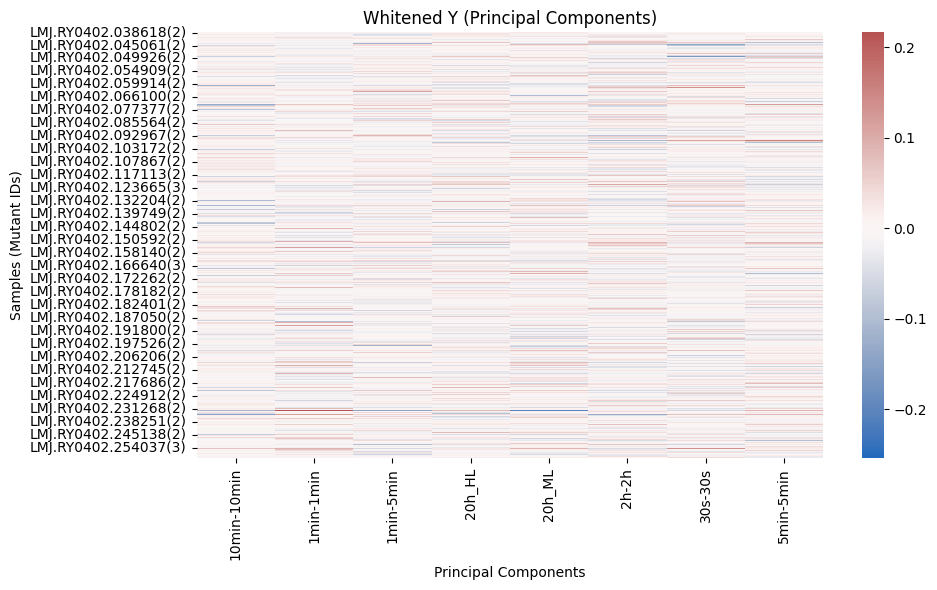

In [59]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
Y_scaled = scaler.fit_transform(Y)

pca = PCA()
Y_pca = pca.fit_transform(Y_scaled)

Y_whitened = Y_pca / pca.singular_values_

scaler = StandardScaler()
Y_scaled = scaler.fit_transform(Y)
pca = PCA()
Y_pca = pca.fit_transform(Y_scaled)
Y_whitened = Y_pca / pca.singular_values_
print("Whitened shape:", Y_whitened.shape)
Y_whitened = pd.DataFrame(Y_whitened, index=Y.index, columns=Y.columns)
print("Whitened shape:", Y_whitened.shape)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(Y_whitened, cmap='vlag', center=0)
plt.title("Whitened Y (Principal Components)")
plt.xlabel("Principal Components")
plt.ylabel("Samples (Mutant IDs)")
plt.tight_layout()
plt.show()


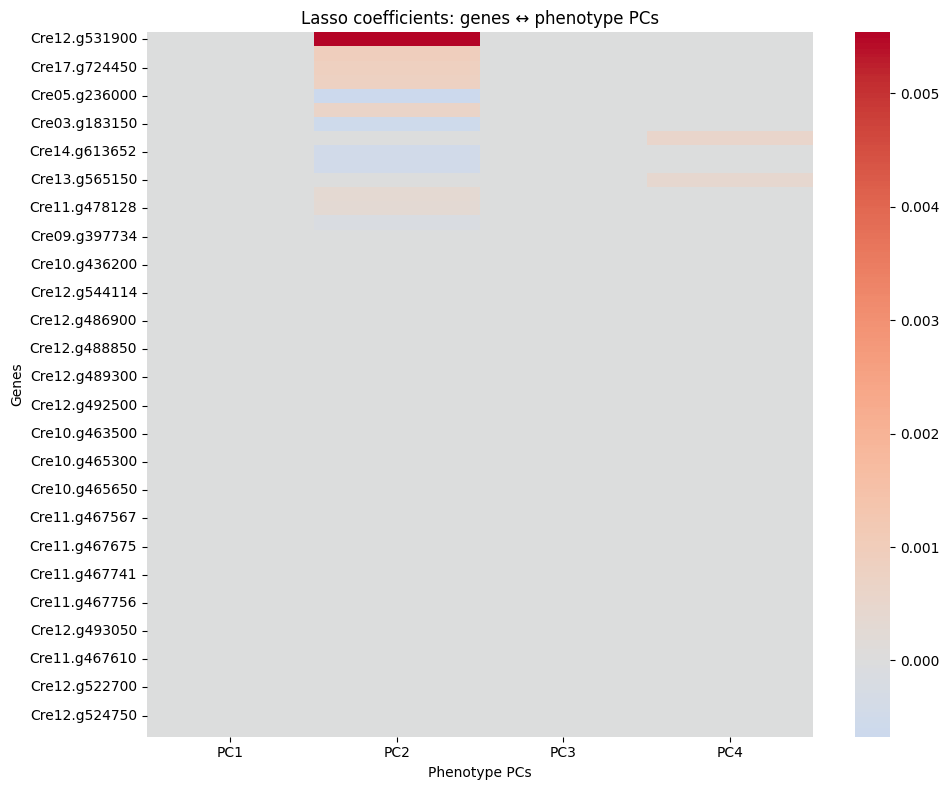

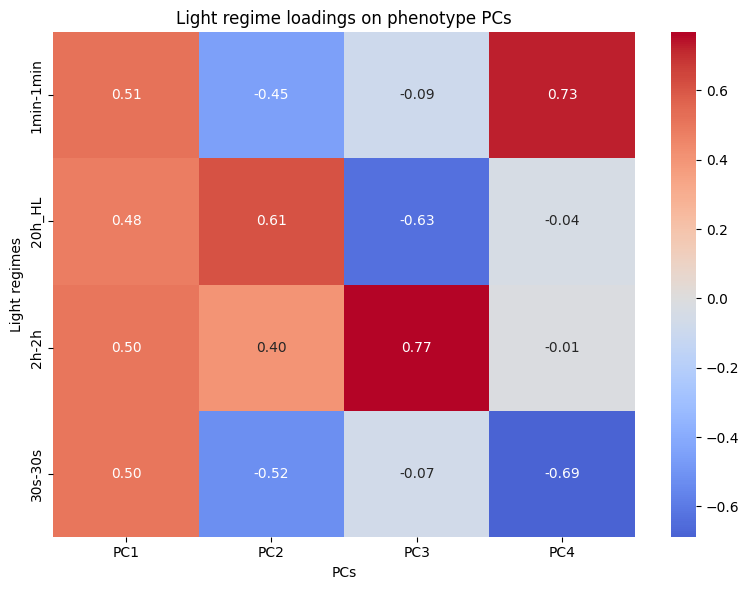

In [94]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LassoCV

# --- 0) Construire X (mutant x gènes) et Y (mutant x light_regime) ---
# df doit contenir: mutant_ID, mutated_genes, light_regime, y2_slope
#df= data#pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/Bayesian_latest_phase2(5.18).csv')
df = df[df['mutant_ID'].notna() & df['mutated_genes'].notna()]

# X: présence de gène (1/0) par mutant
df['presence'] = 1
X = df.pivot_table(index='mutant_ID', columns='mutated_genes',
                   values='presence', fill_value=0)

# Y: slope moyen par light_regime
Y = df.pivot_table(index='mutant_ID', columns='light_regime',
                   values='y2_slope', aggfunc='mean')

# Aligner et nettoyer
common = X.index.intersection(Y.index)
X = X.loc[common]
Y = Y.loc[common]
Y = Y.fillna(Y.mean())                       # imputation simple
X = X.loc[:, X.var() > 0]                    # drop colonnes constantes
# PCA sur Y standardisé 
# --- 1) PCA sur Σ_Y (équivalent à PCA sur Y standardisé) ---
yscaler = StandardScaler()
Y_scaled = yscaler.fit_transform(Y)

pca = PCA(n_components=None)                 # garde toutes les composantes
Y_scores = pca.fit_transform(Y_scaled)       # = Y V (en base standardisée)

# (option) whitening pour variance=1 par PC
Y_white = Y_scores / pca.singular_values_
# Choisir combien de PCs on cible avec le Lasso
K = min(Y_white.shape[1], 6 )               # ex: 6 premières PCs

# --- 2) Lasso: prédire chaque PC de Y via X pour obtenir U parcimonieux ---
# Standardiser X (sans centrer si sparse/binaire)
xscaler = StandardScaler(with_mean=False)
X_scaled = xscaler.fit_transform(X)

alphas = None  # laisse LassoCV choisir
lasso_cv_kwargs = dict(cv=5, n_alphas=100, max_iter=5000, alphas=alphas)

U_coefs = []
for k in range(K):
    yk = Y_white[:, k]
    model = LassoCV(**lasso_cv_kwargs).fit(X_scaled, yk)
    U_coefs.append(model.coef_)

# Matrice U: gènes x PCs
U = pd.DataFrame(np.column_stack(U_coefs),
                 index=X.columns,
                 columns=[f"PC{k+1}" for k in range(K)])

# --- 3) Résultats utiles ---
# a) Scree plot: pca.explained_variance_ratio_ (si tu veux tracer)
explained = pd.Series(pca.explained_variance_ratio_,
                      index=[f"PC{i+1}" for i in range(Y_white.shape[1])])

# b) Top gènes par PC (par valeur absolue des coeffs)
def top_genes_for_pc(U, pc, n=15):
    return U[pc].abs().sort_values(ascending=False).head(n).to_frame("abs_coef").join(U[[pc]])

top_PC1 = top_genes_for_pc(U, "PC1", n=15)
# idem pour PC2, PC3, ...

# --- 4) (option) Y_blanchi sous forme DataFrame avec labels PC ---
Y_whitened_df = pd.DataFrame(Y_white, index=Y.index,
                             columns=[f"PC{i+1}" for i in range(Y_white.shape[1])])

# Objets finaux:
# - explained : variance expliquée par PC (pour scree plot)
# - Y_whitened_df : scores blanchis par PC (échantillons x PCs)
# - U : coefficients Lasso (gènes x PCs) = association gènes↔directions phénotypiques
# - top_PC1 (etc.) : gènes majeurs pour chaque PC
import seaborn as sns
import matplotlib.pyplot as plt

# Sort genes by their strongest coefficient magnitude
gene_order = U.abs().max(axis=1).sort_values(ascending=False).index[:50]  # top 50 genes
plt.figure(figsize=(10, 8))
sns.heatmap(U.loc[gene_order], cmap='coolwarm', center=0, annot=False)
plt.title("Lasso coefficients: genes ↔ phenotype PCs")
plt.xlabel("Phenotype PCs")
plt.ylabel("Genes")
plt.tight_layout()
plt.show()

loadings = pd.DataFrame(pca.components_.T,
                        index=Y.columns,  # original light regimes
                        columns=[f"PC{i+1}" for i in range(pca.n_components_)])

plt.figure(figsize=(8, 6))
sns.heatmap(loadings.iloc[:, :6], cmap='coolwarm', center=0, annot=True, fmt=".2f")
plt.title("Light regime loadings on phenotype PCs")
plt.xlabel("PCs")
plt.ylabel("Light regimes")
plt.tight_layout()
plt.show()